<img src="http://imgur.com/1ZcRyrc.png" style="float: left; margin: 20px; height: 55px">

# ARIMA & SARIMA Lab

---


## Learning Objectives

### Core
- Test a time series for stationarity and determine the order of differencing (d)
- Use ACF/PACF plots to reason about AR and MA terms
- Fit an ARIMA model, forecast, and evaluate it
- Detect seasonality in a series and fit a SARIMA model
- Compare ARIMA vs. SARIMA performance on the same data and explain why one wins

### Target
- Use `auto_arima` to search for (p,d,q) and seasonal (P,D,Q,m) orders
- Produce forecasts with confidence intervals


## Scenario

You are a data scientist and were given the monthly airline passenger counts. Your manager wants a short-term forecast, and wants to know whether a simple ARIMA model is good enough or whether the extra complexity of SARIMA is worth it.

You will build both models on the same data and test which model is better.


## 0. Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.set_printoptions(precision=4)
sns.set(font_scale=1.5)
plt.style.use('fivethirtyeight')

%matplotlib inline
%config InlineBackend.figure_format = 'retina'


In [3]:
from statsmodels.tsa.stattools import acf, pacf, adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tools.eval_measures import rmse
from pmdarima import auto_arima


/Users/sayedali/GA_DSB/env_native/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


<div class="alert alert-info"><strong>What is the below function?:</strong> Function for running the augmented Dickey-Fuller test (adfuller).</div>

In [4]:
def adf_test(series, title=''):
    """
    Pass in a time series and an optional title, returns an ADF report
    """
    print(f'Augmented Dickey-Fuller Test: {title}')
    result = adfuller(series.dropna(),autolag='AIC') # .dropna() handles differenced data
    
    labels = ['ADF test statistic','p-value','# lags used','# observations']
    out = pd.Series(result[0:4],index=labels)

    for key,val in result[4].items():
        out[f'critical value ({key})']=val
        
    print(out.to_string())          # .to_string() removes the line "dtype: float64"
    
    if result[1] <= 0.05:
        print("Strong evidence against the null hypothesis")
        print("Reject the null hypothesis")
        print("Data has no unit root and is stationary")
    else:
        print("Weak evidence against the null hypothesis")
        print("Fail to reject the null hypothesis")
        print("Data has a unit root and is non-stationary")


<div class="alert alert-info"><strong>What is the below function?:</strong> plot ACF and PACF beside each other.</div>

In [5]:
def autocorr_plots(y, lags=None):
    fig, ax = plt.subplots(ncols=2, figsize=(12, 4), sharey=True)
    plot_acf(y, lags=lags, ax=ax[0])
    plot_pacf(y, lags=lags, ax=ax[1])
    return fig, ax


## 1. Load and inspect the data

This is historical monthly airline passenger counts (in thousands).

In [7]:
# 1a. Load the dataset, parsing the 'month' column as dates
df = pd.read_csv('./airline_passengers.csv', parse_dates=['month'])
df.head()

,month,thousands_of_passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


In [8]:
# 1b. Set 'month' as an Index and set the frequency to Monthly-Start (use resamling).
df = df.set_index('month')
df = df.resample('MS').mean()

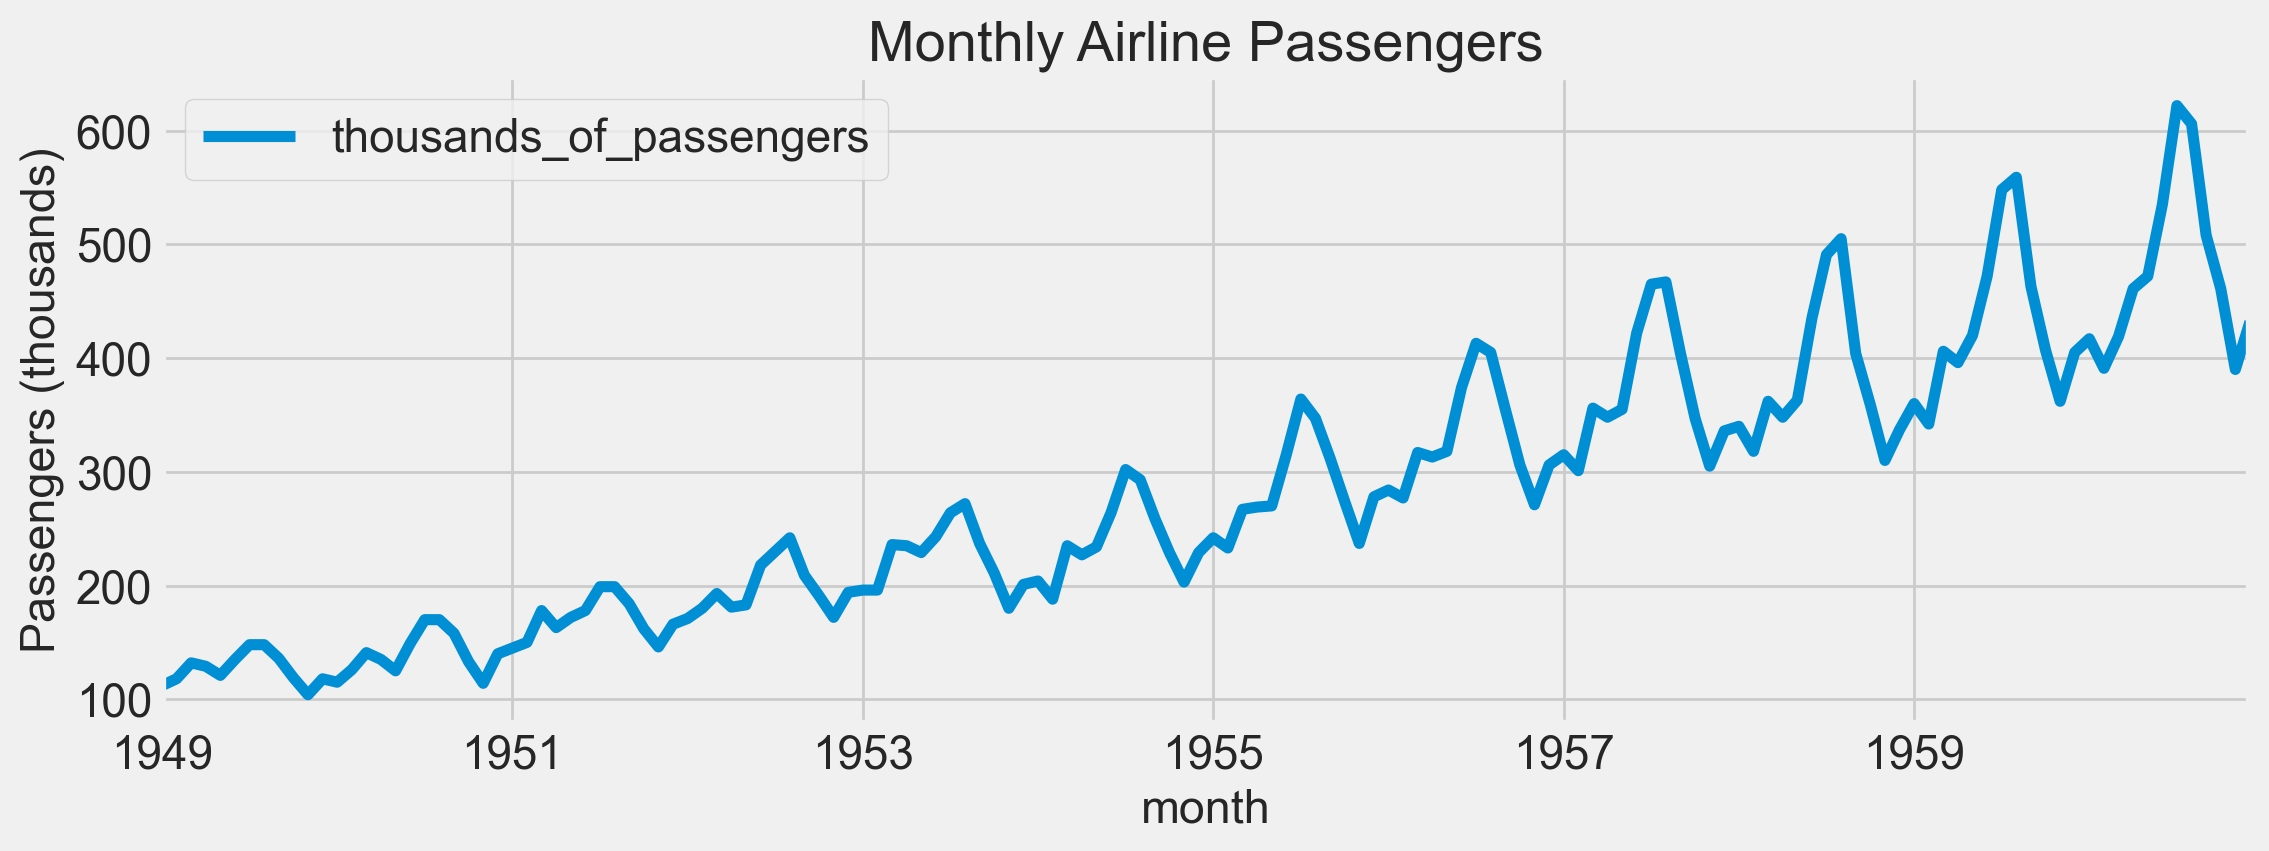

In [9]:
# 1c. Plot the full series and look at shape.
df.plot(figsize=(12, 4), title='Monthly Airline Passengers')
plt.ylabel('Passengers (thousands)')
plt.show()

---
# Part A - ARIMA

We'll start simple: treat this as a general time series and build a non-seasonal ARIMA model. Follow the same workflow: 

> **Stationarity -> Differencing -> ACF/PACF -> Fit -> Evaluate**.


### A1. Check stationarity

In [10]:
# Run adf_test on the passenger series. Is it stationary?
adf_test(df['thousands_of_passengers'])

Augmented Dickey-Fuller Test: 
ADF test statistic        0.815369
p-value                   0.991880
# lags used              13.000000
# observations          130.000000
critical value (1%)      -3.481682
critical value (5%)      -2.884042
critical value (10%)     -2.578770
Weak evidence against the null hypothesis
Fail to reject the null hypothesis
Data has a unit root and is non-stationary


### A2. Difference until stationary

If the series isn't stationary, difference it (`.diff()`) and re-run the ADF test. Keep track of how many differences it took - that's your `d`.

In [11]:
# Difference once and re-test
adf_test(df['thousands_of_passengers'].diff())

Augmented Dickey-Fuller Test: 
ADF test statistic       -2.829267
p-value                   0.054213
# lags used              12.000000
# observations          130.000000
critical value (1%)      -3.481682
critical value (5%)      -2.884042
critical value (10%)     -2.578770
Weak evidence against the null hypothesis
Fail to reject the null hypothesis
Data has a unit root and is non-stationary


In [12]:
# If needed, difference a second time and re-test
adf_test(df['thousands_of_passengers'].diff().diff())

Augmented Dickey-Fuller Test: 
ADF test statistic     -1.638423e+01
p-value                 2.732892e-29
# lags used             1.100000e+01
# observations          1.300000e+02
critical value (1%)    -3.481682e+00
critical value (5%)    -2.884042e+00
critical value (10%)   -2.578770e+00
Strong evidence against the null hypothesis
Reject the null hypothesis
Data has no unit root and is stationary


**Write down your `d` value here:**

`d = 2`

### A3. ACF / PACF on the differenced series

Use `autocorr_plots()` on your *stationary* (differenced) series.

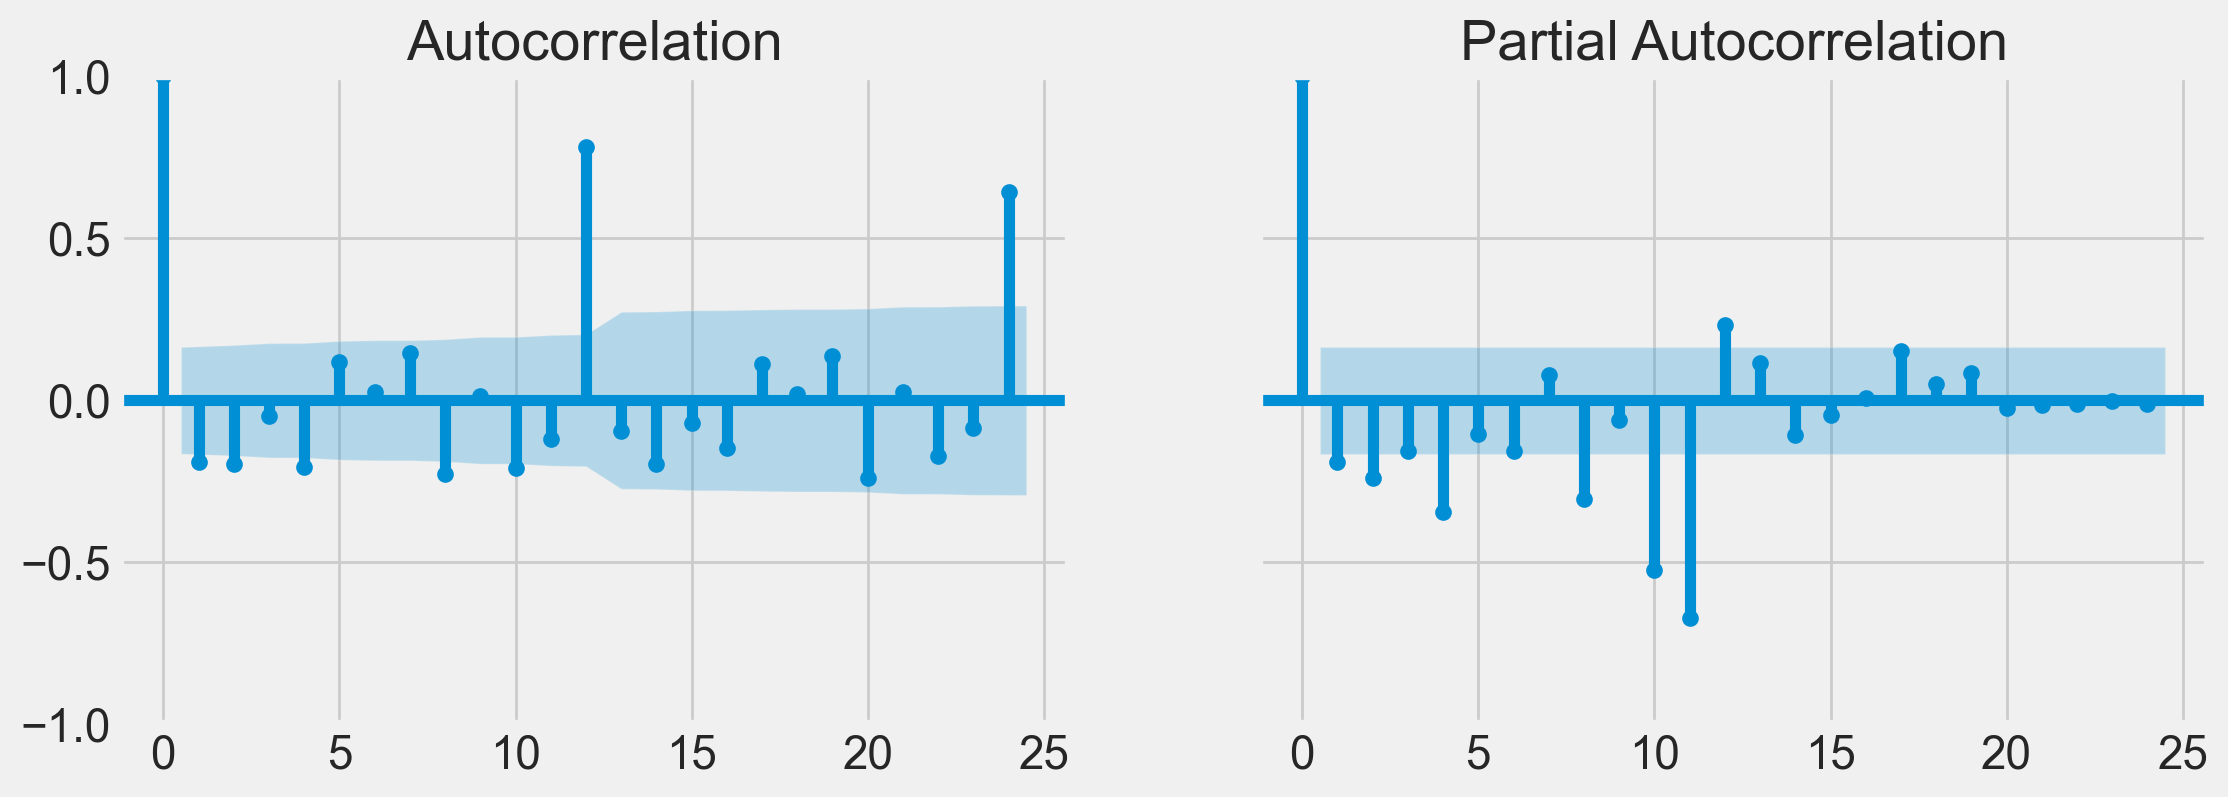

In [16]:
# Plot ACF and PACF on the differenced series, lags=24
autocorr_plots(df['thousands_of_passengers'].diff().diff().dropna(), lags=24);

**Based on the plots above, what would you guess for `p` and `q`?**

- p (AR terms): 1
- q (MA terms): 1

### A4. Confirm with auto_arima

Now check your manual guess against `auto_arima`. Keep `seasonal=False` as we are not modeling seasonality in Part A.

In [19]:
import warnings
warnings.filterwarnings('ignore')

In [21]:
# Run auto_arima with seasonal=False and print the summary
auto_fit = auto_arima(df['thousands_of_passengers'], 
                          start_p=0, start_q=0,    # starting p and q
                          max_p=2, max_q=2,        # maximum p and q
                          m=1,                     # m is used for seasonality, m=1 means no seasonality (cover this later)
                          seasonal=False,          # We do not want seasonality here
                          d=None,                  # The order of first-differencing. If None (by default), get it automatically
                          trace=True,              # Whether to print status on the fits
                          error_action='ignore',   # we don't want to know if an order does not work
                          suppress_warnings=True,  # we don't want convergence warnings
                          )           

auto_fit.summary()

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1415.278, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1403.473, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1398.827, Time=0.03 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1413.909, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1396.121, Time=0.02 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.04 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.03 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=1398.386, Time=0.02 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=1397.975, Time=0.01 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.06 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=1394.683, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=1397.258, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=1401.852, Time=0.01 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=1378.338, Time=0.01 sec
 ARIMA(2,1,0)(0,0,0)[0]             : AIC=1396.5

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  144
Model:               SARIMAX(2, 1, 1)   Log Likelihood                -685.169
Date:                Mon, 17 Aug 2026   AIC                           1378.338
Time:                        22:21:34   BIC                           1390.190
Sample:                    01-01-1949   HQIC                          1383.154
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0907      0.083     13.190      0.000       0.929       1.253
ar.L2         -0.4890      0.097     -5.046      0.000      -0.679      -0.299
ma.L1         -0.8439      0.073    -11.486      0.000      -0.988      -0.700
sigma2       844.6059    103.095      8.192      0.000     642.543    1046.669
===================================================================================
Ljung-Box (L1) (Q):                   0.94   Jarque-Bera (JB):                 2.15
Prob(Q):                              0.33   Prob(JB):                         0.34
Heteroskedasticity (H):               7.67   Skew:                             0.30
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.03
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### A5. Train, Test, and Split

Hold out the last 12 months as your test set.

In [22]:
# Split into df_train (all but last 12 rows) and df_test (last 12 rows)
df_train = df.iloc[:-12]
df_test = df.iloc[-12:]

### A6. Fit the ARIMA model

Use the (p,d,q) order from A4.

In [23]:
# Fit ARIMA(p,d,q) on the training set
model_arima = ARIMA(df_train['thousands_of_passengers'], order=(2,1, 1))
result_arima = model_arima.fit()

result_arima.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                  SARIMAX Results                                  
===================================================================================
Dep. Variable:     thousands_of_passengers   No. Observations:                  132
Model:                      ARIMA(2, 1, 1)   Log Likelihood                -619.131
Date:                     Mon, 17 Aug 2026   AIC                           1246.262
Time:                             22:26:46   BIC                           1257.763
Sample:                         01-01-1949   HQIC                          1250.936
                              - 12-01-1959                                         
Covariance Type:                       opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0698      0.094     11.323      0.000       0.885       1.255
ar.L2         -0.4734      0.101     -4.670      0.000      -0.672      -0.275
ma.L1         -0.8402      0.085     -9.851      0.000      -1.007      -0.673
sigma2       741.2092     92.892      7.979      0.000     559.145     923.274
===================================================================================
Ljung-Box (L1) (Q):                   0.94   Jarque-Bera (JB):                 1.71
Prob(Q):                              0.33   Prob(JB):                         0.42
Heteroskedasticity (H):               6.69   Skew:                             0.28
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.00
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### A7. Predict on the test set

In [24]:
# Predict over the test period
start = len(df_train)
end = len(df_train) + len(df_test) - 1

pred_arima = result_arima.predict(start=start, end=end)
pred_arima

1960-01-01    437.013051
1960-02-01    450.903711
1960-03-01    450.608213
1960-04-01    443.715784
1960-05-01    436.482007
1960-06-01    432.006253
1960-07-01    430.642700
1960-08-01    431.302911
1960-09-01    432.654770
1960-10-01    433.788454
1960-11-01    434.361280
1960-12-01    434.437378
Freq: MS, Name: predicted_mean, dtype: float64

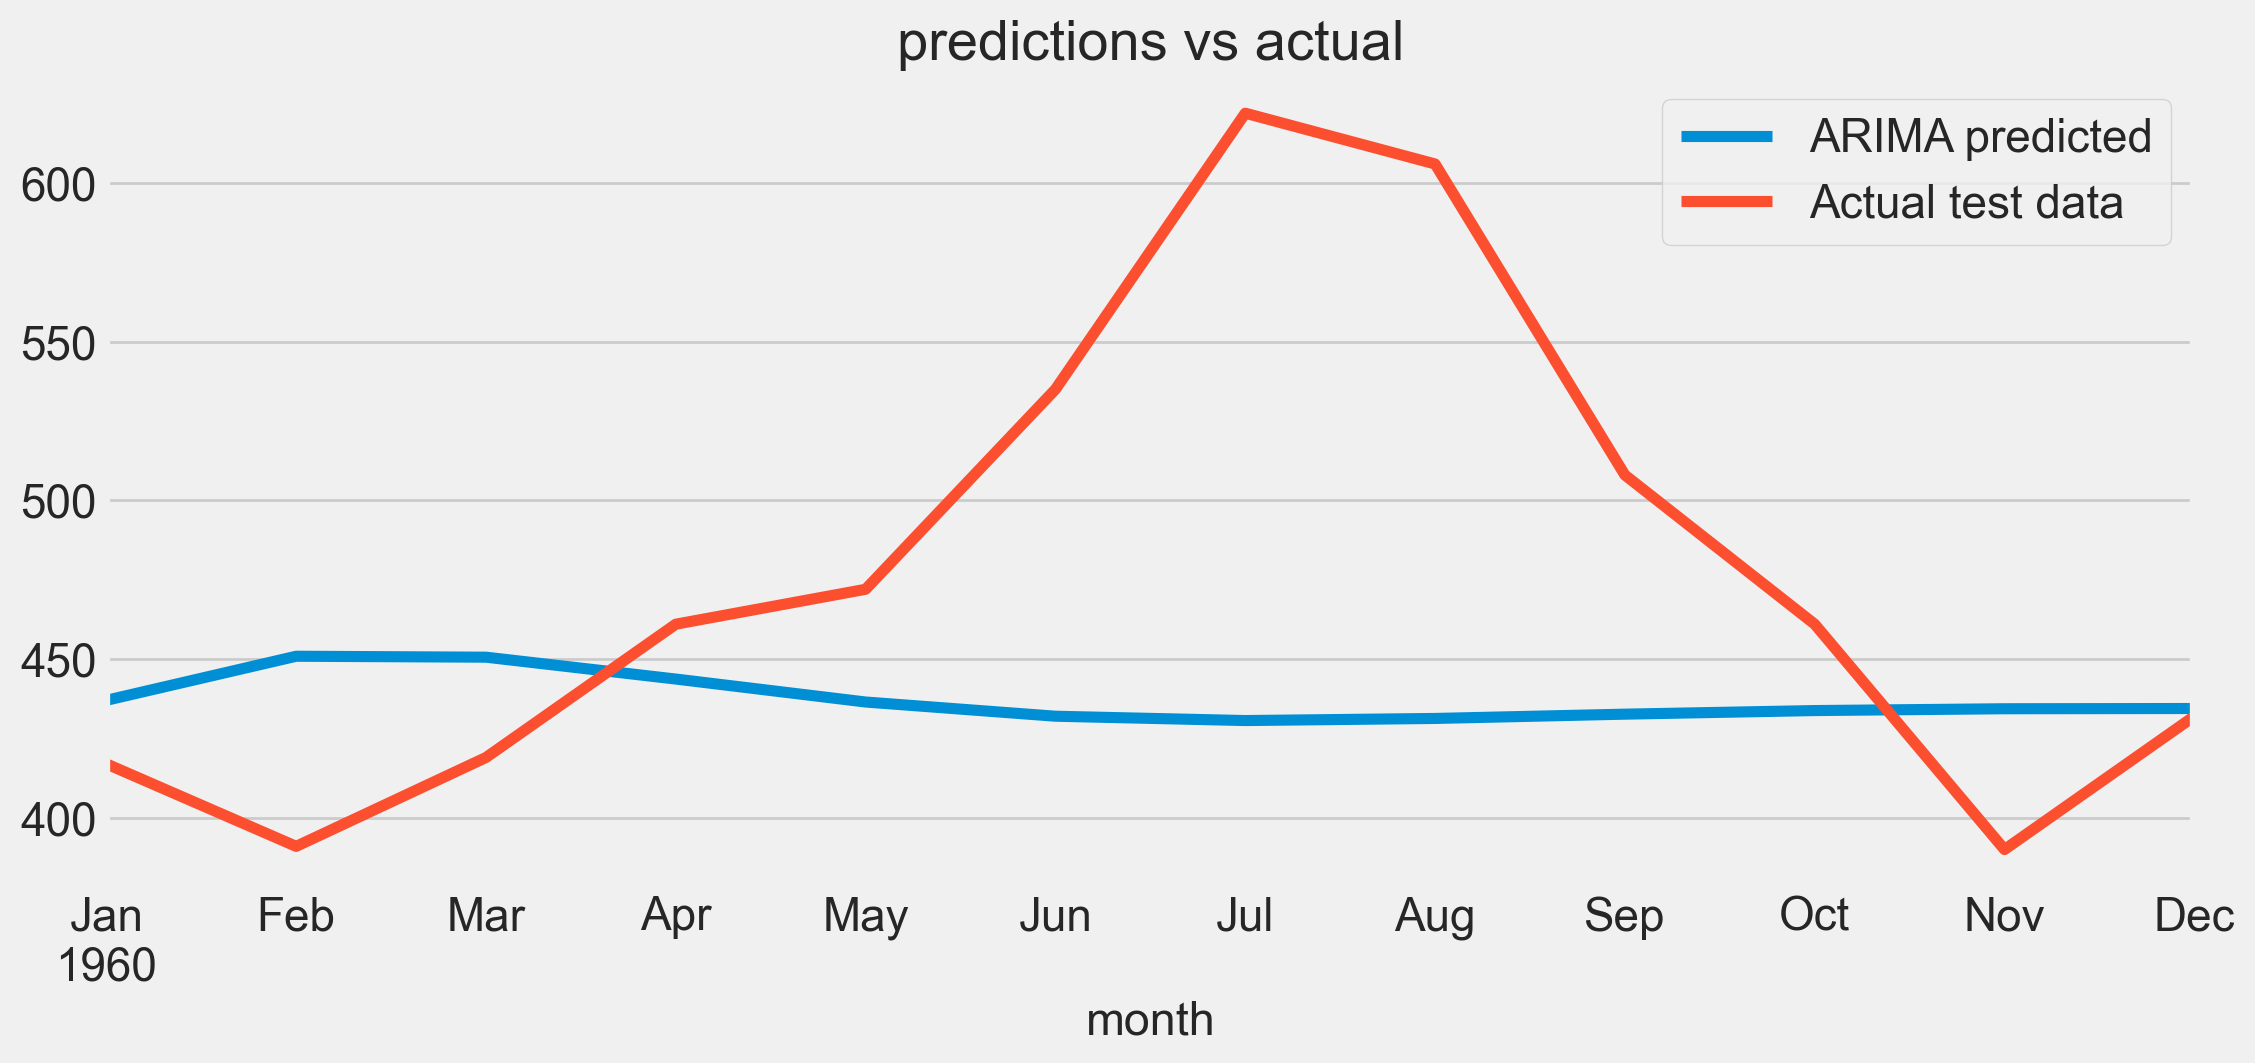

In [25]:
# Plot the test data vs predictions
title = 'predictions vs actual'
ax = pred_arima.plot(legend=True, figsize=(12, 5), title=title)
df_test['thousands_of_passengers'].plot(legend=True, ax=ax)
ax.legend(['ARIMA predicted', 'Actual test data'])
plt.show()

### A8. Evaluate

Compute RMSE for the ARIMA model. Also print the mean of the series so you have something to compare the error against.

In [26]:
# Compute RMSE
rmsearima = rmse(df_test['thousands_of_passengers'], pred_arima)

print(f'ARIMA RMSE: {rmsearima:.4f}')
print(f'Mean: {df["thousands_of_passengers"].mean():.4f}')

ARIMA RMSE: 87.8844
Mean: 280.2986


---
# Part B - SARIMA

Now let's actually look at *why* the ARIMA forecast missed. This is where we introduce seasonality.


### B1. Seasonal decomposition

Run `seasonal_decompose` on the **original** (undifferenced) series and plot it.

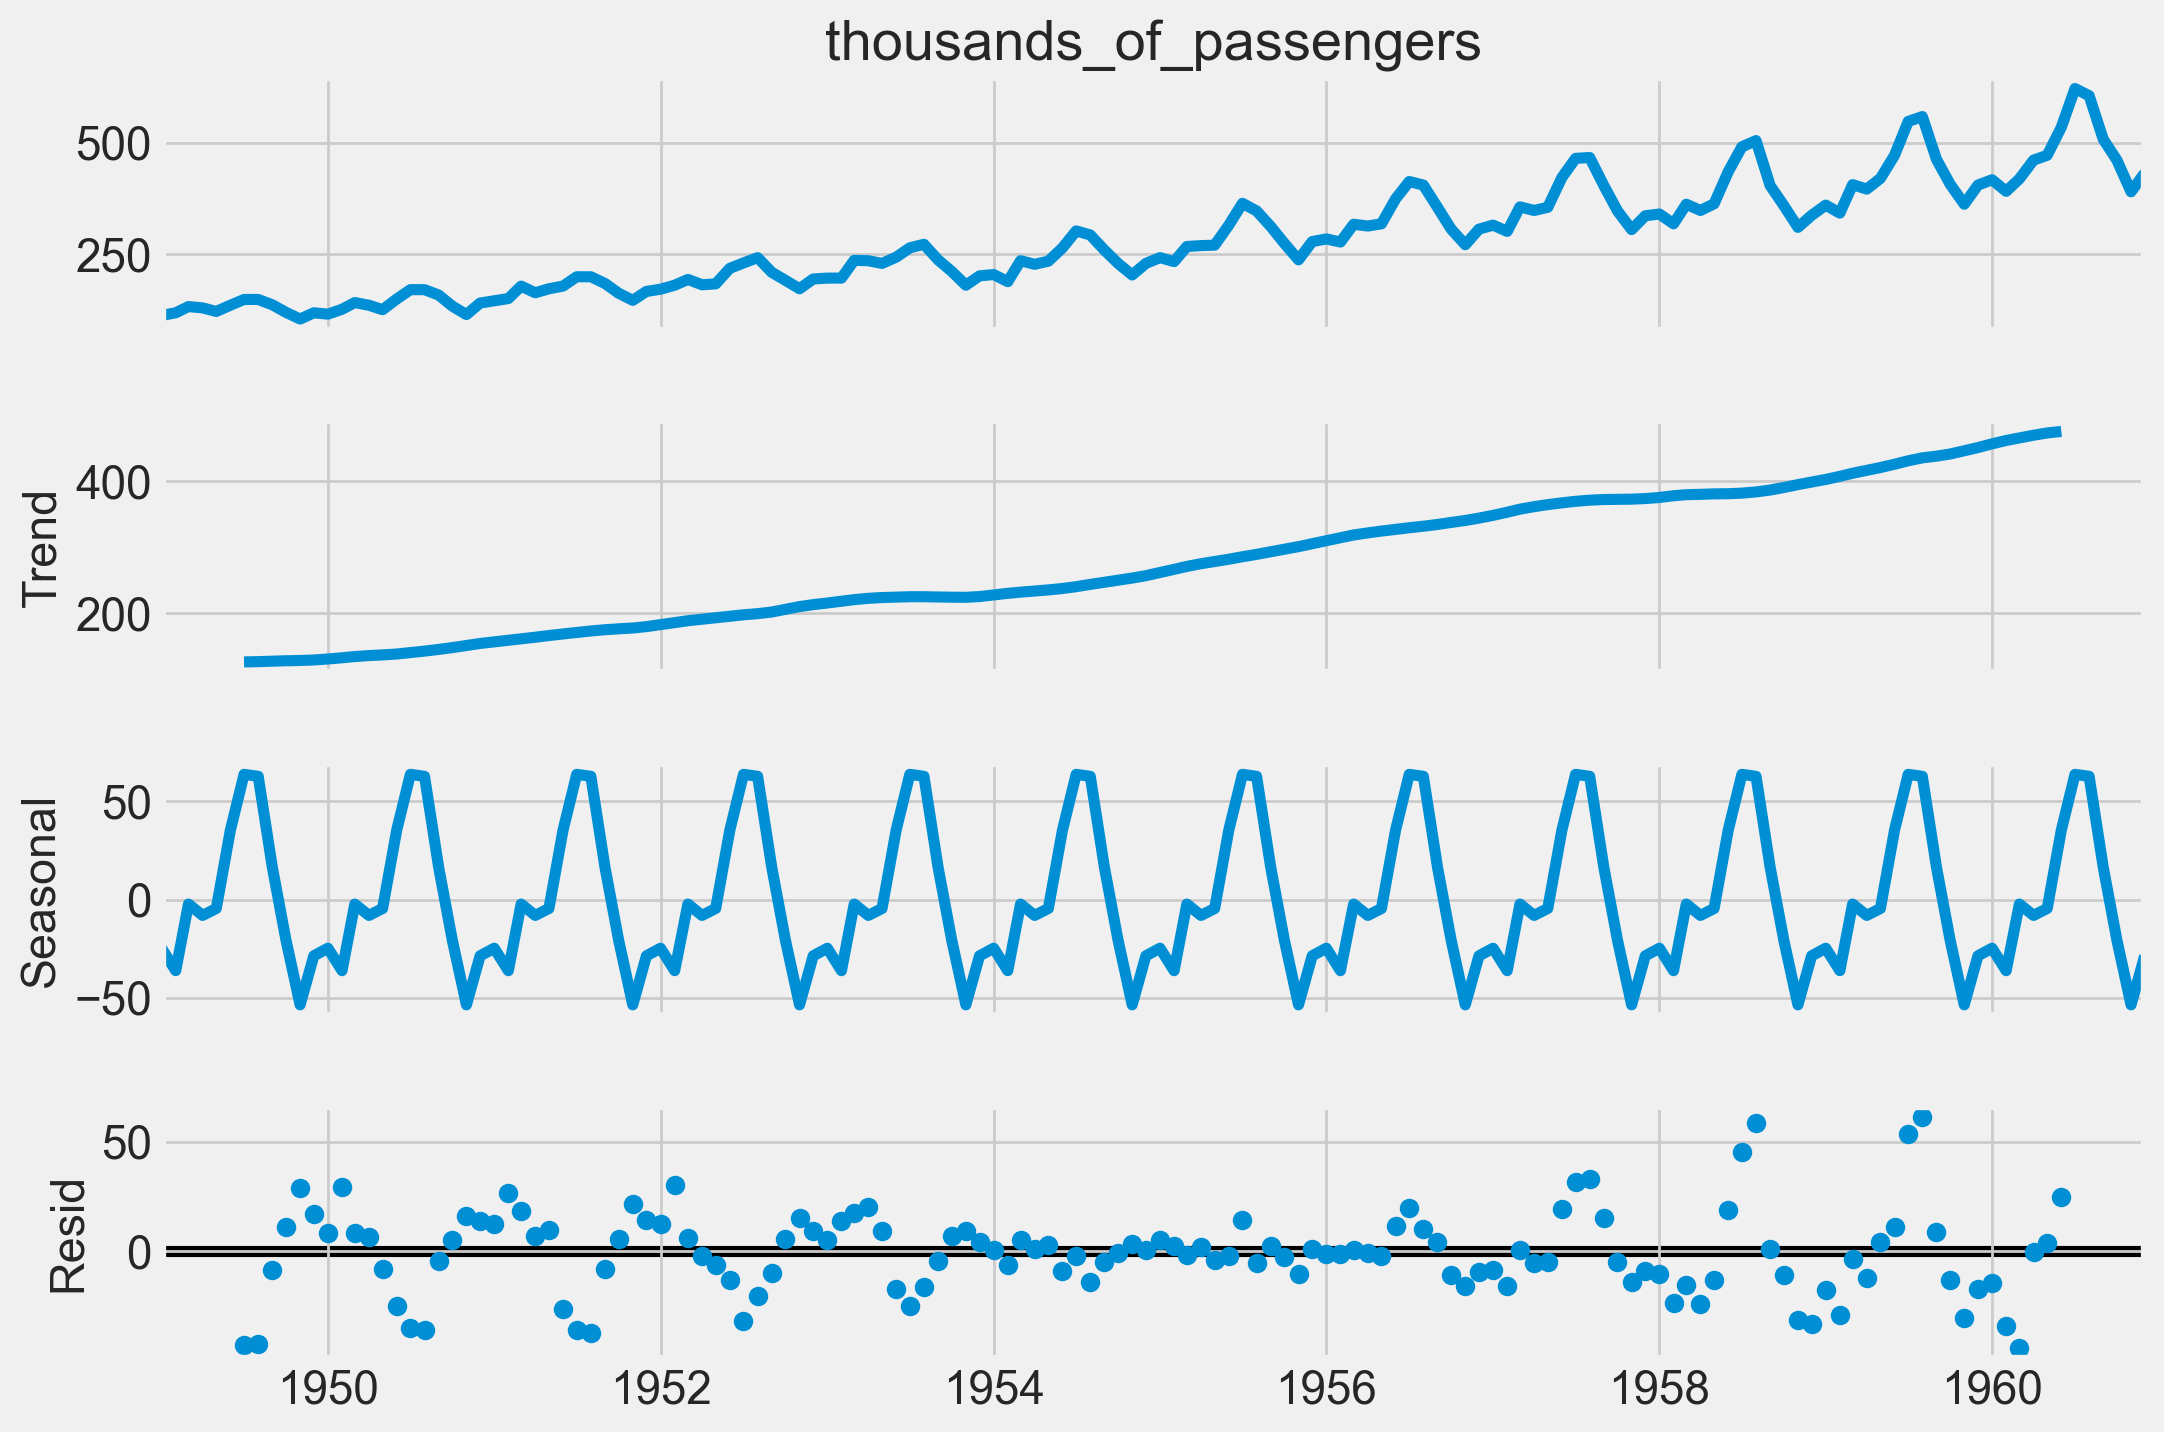

In [27]:
#YOUR CODE HERE
dcomp = seasonal_decompose(df['thousands_of_passengers'], period=12)

dcomp.plot()
plt.gcf().set_size_inches(12, 8)
plt.show()

**What do you see in the seasonal component?** Is there a repeating pattern? What's the period (how many months before it repeats)?

### B2. Search for a seasonal order with auto_arima

Run `auto_arima` again, this time with `seasonal=True` and `m=12` (12 months per cycle).

In [28]:
#YOUR CODE HERE
seasonalmodel = auto_arima(df['thousands_of_passengers'],
                                 seasonal=True,     
                                 m=12,            
                                 trace=True,
                                 error_action='ignore',
                                 suppress_warnings=True)

seasonalmodel.summary()

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,1,1)[12]             : AIC=1020.048, Time=0.69 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=1031.508, Time=0.01 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=1020.393, Time=0.04 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=1021.003, Time=0.10 sec
 ARIMA(2,1,2)(0,1,1)[12]             : AIC=1019.935, Time=0.28 sec
 ARIMA(2,1,2)(0,1,0)[12]             : AIC=1019.290, Time=0.08 sec
 ARIMA(2,1,2)(1,1,0)[12]             : AIC=1019.546, Time=0.25 sec
 ARIMA(1,1,2)(0,1,0)[12]             : AIC=1024.160, Time=0.04 sec
 ARIMA(2,1,1)(0,1,0)[12]             : AIC=1017.847, Time=0.07 sec
 ARIMA(2,1,1)(1,1,0)[12]             : AIC=1017.914, Time=0.26 sec
 ARIMA(2,1,1)(0,1,1)[12]             : AIC=1018.359, Time=0.24 sec
 ARIMA(2,1,1)(1,1,1)[12]             : AIC=1018.248, Time=0.43 sec
 ARIMA(1,1,1)(0,1,0)[12]             : AIC=1022.393, Time=0.02 sec
 ARIMA(2,1,0)(0,1,0)[12]             : AIC=1022.393, Time=0.02 sec
 ARIMA(3,1,1)(0,1,0

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                                   y   No. Observations:                  144
Model:             SARIMAX(2, 1, 1)x(0, 1, [], 12)   Log Likelihood                -504.923
Date:                             Mon, 17 Aug 2026   AIC                           1017.847
Time:                                     23:30:51   BIC                           1029.348
Sample:                                 01-01-1949   HQIC                          1022.520
                                      - 12-01-1960                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5959      0.085      6.987      0.000       0.429       0.763
ar.L2          0.2143      0.091      2.343      0.019       0.035       0.394
ma.L1         -0.9819      0.038    -25.601      0.000      -1.057      -0.907
sigma2       129.3144     14.557      8.884      0.000     100.784     157.845
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 7.68
Prob(Q):                              0.98   Prob(JB):                         0.02
Heteroskedasticity (H):               2.33   Skew:                            -0.01
Prob(H) (two-sided):                  0.01   Kurtosis:                         4.19
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

**Write down the order and seasonal_order suggested:**

- order (p,d,q) = (2,1,1)
- seasonal_order (P,D,Q,m) = (0,1,0,12)

### B3. Fit the SARIMA model

Use `SARIMAX` with both `order` and `seasonal_order`, fit on `df_train`.

In [29]:
#YOUR CODE HERE
model_sarima = SARIMAX(df_train['thousands_of_passengers'],
                       order=(2, 1, 1),
                       seasonal_order=(0, 1, 0, 12))
result_sarima = model_sarima.fit()
result_sarima.summary()

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            4     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  3.42129D+00    |proj g|=  2.27842D-01

At iterate    5    f=  3.39217D+00    |proj g|=  1.21741D-02

At iterate   10    f=  3.39006D+00    |proj g|=  2.06913D-03

At iterate   15    f=  3.39003D+00    |proj g|=  1.15981D-03

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    4     18     33      1     0     0   1.040D-05   3.390D+00
  F =   3.3900246510401919     

CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH             


 This problem is unconstrained.

   evaluations in the last line search.  Termination
   may possibly be caused by a bad search direction.


<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:             thousands_of_passengers   No. Observations:                  132
Model:             SARIMAX(2, 1, 1)x(0, 1, [], 12)   Log Likelihood                -447.483
Date:                             Mon, 17 Aug 2026   AIC                            902.967
Time:                                     23:37:26   BIC                            914.083
Sample:                                 01-01-1949   HQIC                           907.481
                                      - 12-01-1959                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5253      0.929     -0.566      0.572      -2.345       1.295
ar.L2          0.0110      0.275      0.040      0.968      -0.529       0.551
ma.L1          0.3064      0.935      0.328      0.743      -1.527       2.140
sigma2       108.0094     13.498      8.002      0.000      81.553     134.466
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 1.39
Prob(Q):                              0.97   Prob(JB):                         0.50
Heteroskedasticity (H):               1.47   Skew:                            -0.09
Prob(H) (two-sided):                  0.23   Kurtosis:                         3.50
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### B4. Predict on the test set, with confidence intervals

This time, also pull the confidence interval so you can plot forecast uncertainty.

In [30]:
#YOUR CODE HERE
start = len(df_train)
end = len(df_train) + len(df_test) - 1

pred_sarima_obj = result_sarima.get_prediction(start=start, end=end)
pred_sarima = pred_sarima_obj.predicted_mean
conf_int = pred_sarima_obj.conf_int()

pred_sarima

1960-01-01    425.135147
1960-02-01    408.815435
1960-03-01    471.901434
1960-04-01    462.399947
1960-05-01    486.128076
1960-06-01    538.276345
1960-07-01    614.195484
1960-08-01    625.239583
1960-09-01    529.215533
1960-10-01    473.228649
1960-11-01    428.221496
1960-12-01    471.225397
Freq: MS, Name: predicted_mean, dtype: float64

### B5. Evaluate

In [32]:
# Compute RMSE
rmse_sarima = rmse(df_test['thousands_of_passengers'], pred_sarima)

print(f'SARIMA RMSE: {rmse_sarima:.4f}')


SARIMA RMSE: 24.8741


### B6. ARIMA vs. SARIMA

Plot both sets of predictions against the actual test values side by side and print both RMSEs together.

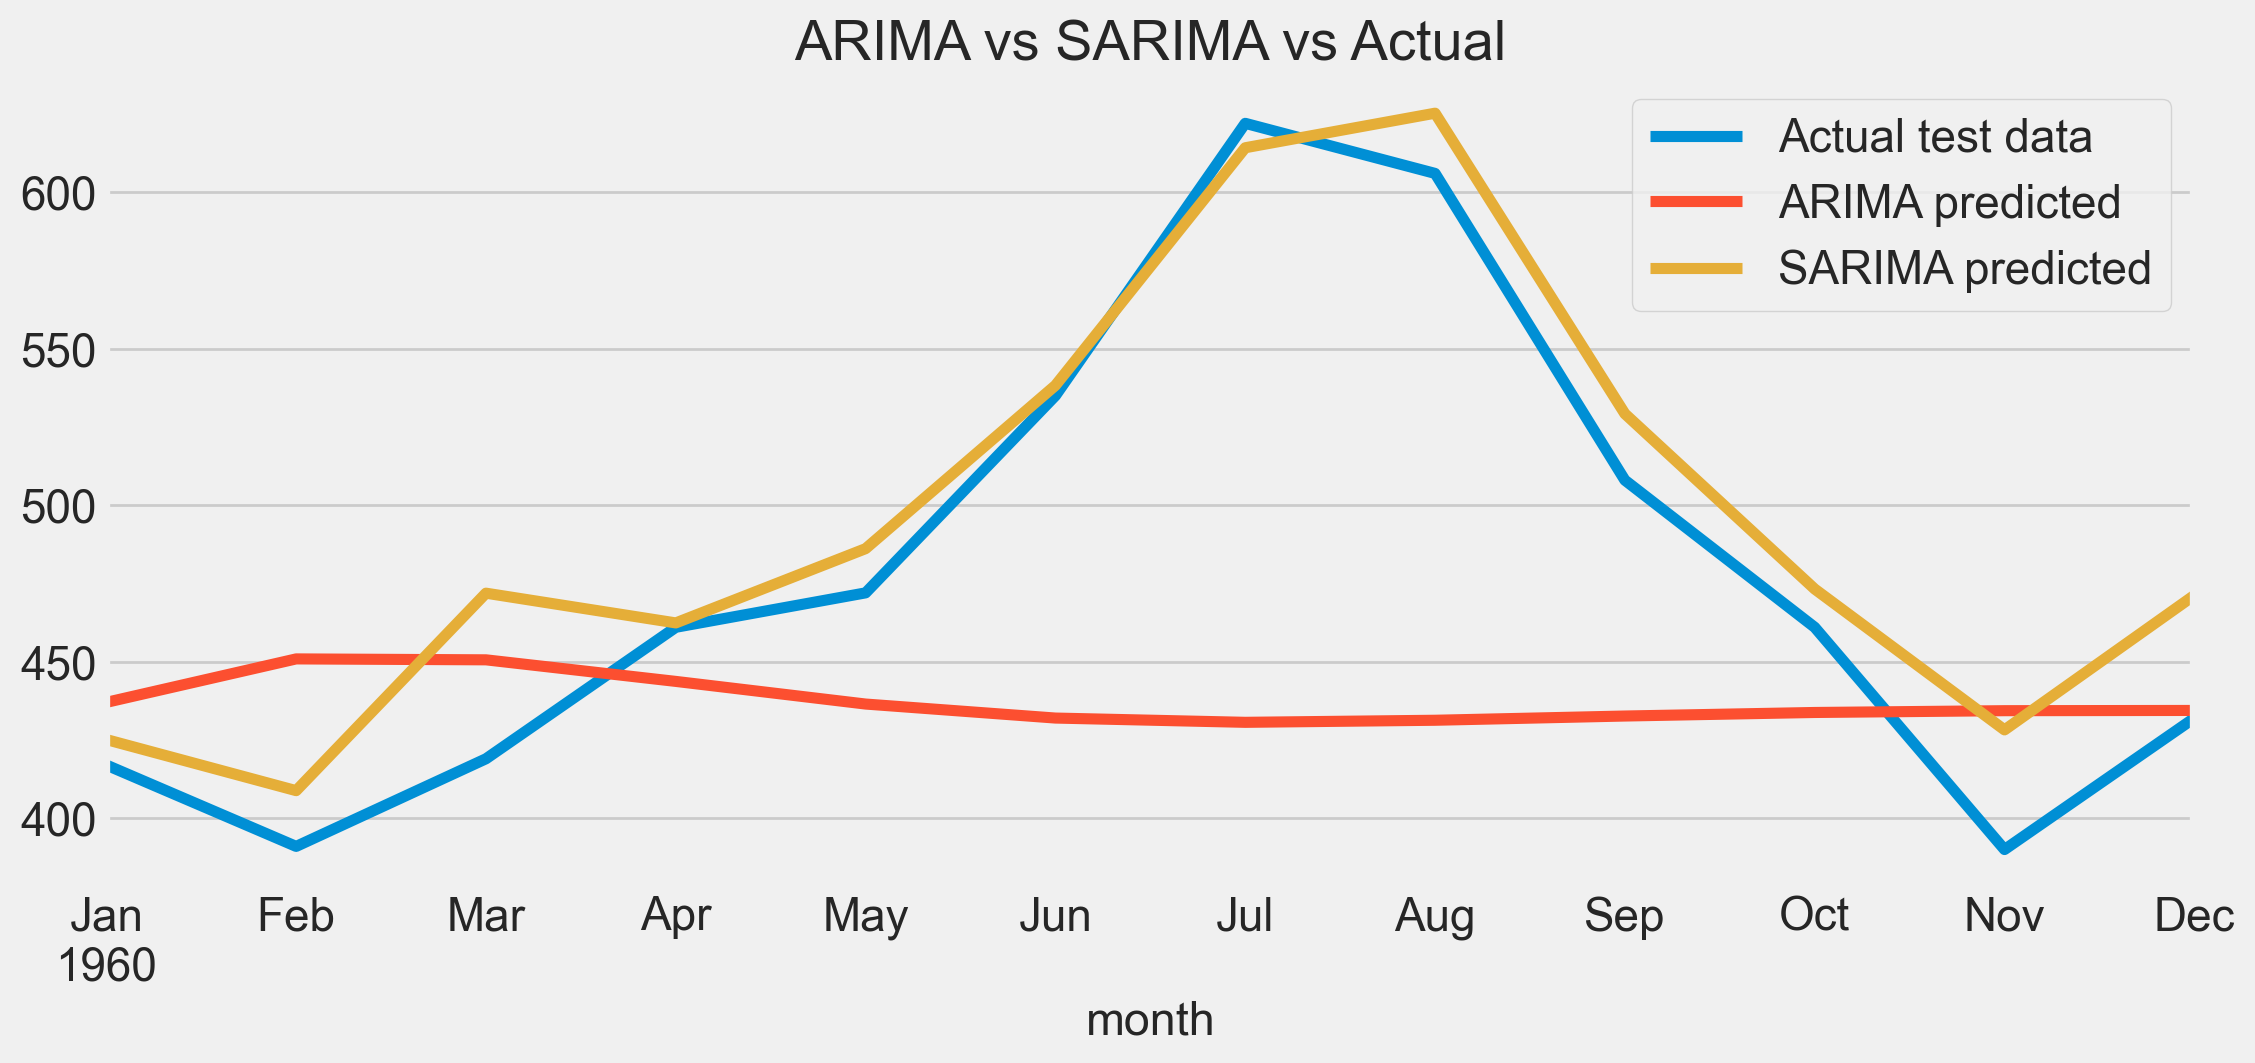

In [33]:
#YOUR CODE HERE

title = 'ARIMA vs SARIMA vs Actual'
ax = df_test['thousands_of_passengers'].plot(legend=True, figsize=(12, 5), title=title)
pred_arima.plot(legend=True, ax=ax)
pred_sarima.plot(legend=True, ax=ax)
ax.legend(['Actual test data', 'ARIMA predicted', 'SARIMA predicted'])
plt.show()


<a id='forecast'></a>
## 2. Forecast the future

Retrain your **winning model** on the *full* dataset and forecast 12 months into the future

**Bonus**: *Plot the forecast with confidence intervals*.

In [ ]:
#YOUR CODE HERE

## Takeaways
- Seasonality is easy to miss if you don't plot/decompose the data, hence, always look before you model.
- SARIMA isn't automatically the right call; it's justified when the seasonal component is real and the added parameters actually reduce error on held-out data.
- Always evaluate on a proper time-ordered train,test, and split.


## Additional Resources
- [statsmodels SARIMAX documentation](https://www.statsmodels.org/stable/generated/statsmodels.tsa.statespace.sarimax.SARIMAX.html)
- [pmdarima auto_arima documentation](https://alkaline-ml.com/pmdarima/modules/generated/pmdarima.arima.auto_arima.html)
- [Forecasting: Principles and Practice - Seasonal ARIMA](https://otexts.com/fpp2/seasonal-arima.html)
